# entrenamiento del modelo cnn
clasificador de celulares, laptops y relojes.

## importación de librerías

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

## carga de datos y split

In [2]:
# configuración de parámetros
batch_size = 16
img_height = 224
img_width = 224
data_dir = "dataset"

# carga del dataset desde la carpeta y split del 20%
print("cargando datos de entrenamiento...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

print("cargando datos de validación...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print(f"clases detectadas: {class_names}")

cargando datos de entrenamiento...
Found 225 files belonging to 3 classes.
Using 180 files for training.
cargando datos de validación...
Found 225 files belonging to 3 classes.
Using 45 files for validation.
clases detectadas: ['celulares', 'laptops', 'relojes']


## data augmentation

In [3]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal", input_shape=(img_height, img_width, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

/Users/javier/Downloads/clasificador-objetos/venv/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## arquitectura de la cnn

In [4]:
# construcción de la cnn capa por capa
num_classes = len(class_names)

modelo = models.Sequential([
    data_augmentation,
    # estandarización de los pixeles de 0-255 a 0-1
    layers.Rescaling(1./255),
    
    # extracción de características (convoluciones)
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    
    # clasificación final
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

modelo.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

modelo.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,819 (49.36 MB)

 Trainable params: 12,938,819 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

## entrenamiento

In [5]:
epochs = 15
print("iniciando entrenamiento...")
history = modelo.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)
print("entrenamiento finalizado.")

iniciando entrenamiento...
Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 396ms/step - accuracy: 0.3167 - loss: 1.2865 - val_accuracy: 0.4444 - val_loss: 0.9832
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 423ms/step - accuracy: 0.4111 - loss: 1.0638 - val_accuracy: 0.6222 - val_loss: 0.9290
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 390ms/step - accuracy: 0.5222 - loss: 1.0302 - val_accuracy: 0.6444 - val_loss: 0.9722
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 376ms/step - accuracy: 0.5667 - loss: 0.9229 - val_accuracy: 0.6889 - val_loss: 0.9911
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 465ms/step - accuracy: 0.6611 - loss: 0.8454 - val_accuracy: 0.6667 - val_loss: 0.7451
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 410ms/step - accuracy: 0.5111 - loss: 0.9534 - val_accuracy: 0.6667 - val_loss: 0.7393
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 412ms/step - accuracy: 0.6833 - loss: 0.8000 - val_accuracy: 0.7556 - val_loss: 0.6462
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 413ms/step - accuracy: 0.7056 - loss

## evaluación y resultados

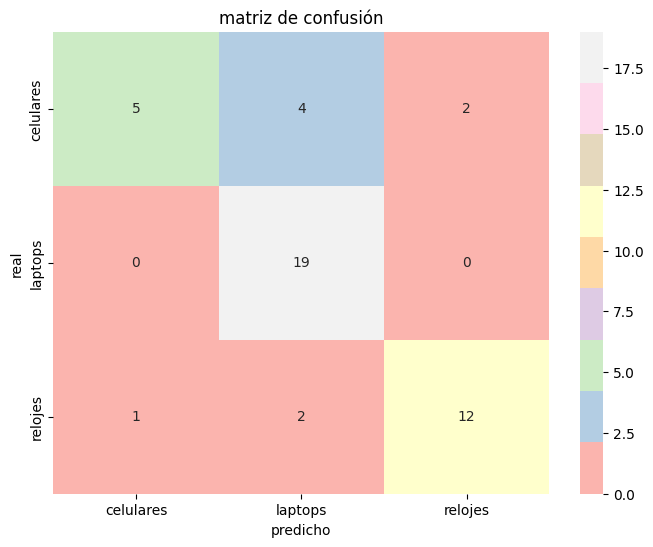

              precision    recall  f1-score   support

   celulares       0.83      0.45      0.59        11
     laptops       0.76      1.00      0.86        19
     relojes       0.86      0.80      0.83        15

    accuracy                           0.80        45
   macro avg       0.82      0.75      0.76        45
weighted avg       0.81      0.80      0.78        45



In [10]:
# generación de predicciones sobre el set de validación
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = modelo.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

# matriz de confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Pastel1', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('predicho')
plt.ylabel('real')
plt.title('matriz de confusión')
plt.show()

# reporte detallado
print(classification_report(y_true, y_pred, target_names=class_names))

---

# fine-tuning

## importación de nuevas herramientas

In [11]:
from tensorflow.keras import regularizers, callbacks

## data augmentation 2

In [12]:
# agregamos traslación y contraste para mayor generalización
data_augmentation_robusto = tf.keras.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2), 
    layers.RandomZoom(0.2),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    layers.RandomContrast(0.1)
])

## arquitectura 2

In [13]:
# creamos una instancia completamente nueva para no pisar el modelo anterior
modelo_robusto = models.Sequential([
    data_augmentation_robusto,
    layers.Rescaling(1./255),
    
    # bloque 1
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    
    # bloque 2
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    
    # bloque 3
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),
    
    # bloque 4
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.4),
    
    # clasificación final
    layers.Flatten(),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

modelo_robusto.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

## entrenamiento 2

In [14]:
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)

epochs_robust = 30
print("iniciando entrenamiento del modelo robusto...")

history_robusto = modelo_robusto.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs_robust,
    callbacks=[early_stop, reduce_lr]
)
print("entrenamiento finalizado.")

iniciando entrenamiento del modelo robusto...
Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 795ms/step - accuracy: 0.4889 - loss: 1.8775 - val_accuracy: 0.2444 - val_loss: 2.4236 - learning_rate: 0.0010
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 621ms/step - accuracy: 0.5444 - loss: 1.7112 - val_accuracy: 0.2444 - val_loss: 4.2045 - learning_rate: 0.0010
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 580ms/step - accuracy: 0.5278 - loss: 1.6384 - val_accuracy: 0.3778 - val_loss: 3.4587 - learning_rate: 0.0010
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 621ms/step - accuracy: 0.6167 - loss: 1.4334 - val_accuracy: 0.4222 - val_loss: 3.0861 - learning_rate: 0.0010
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 596ms/step - accuracy: 0.5778 - loss: 1.5526 - val_accuracy: 0.4444 - val_loss: 4.9708 - learning_rate: 5.0000e-04
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 614ms/step - accuracy: 0.6444 - loss: 1.3493 - val_accuracy: 0.4222 - val_loss: 3.5069 - learning_rate: 5.0000e-04
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━

In [15]:
# evaluamos especificamente este nuevo modelo
y_true_robusto = []
y_pred_robusto = []

for images, labels in val_ds:
    predictions = modelo_robusto.predict(images, verbose=0)
    y_true_robusto.extend(labels.numpy())
    y_pred_robusto.extend(np.argmax(predictions, axis=1))

print("\n--- reporte del modelo robusto ---")
print(classification_report(y_true_robusto, y_pred_robusto, target_names=class_names))

# guardamos esta segunda version
modelo_robusto.save('modelo_robusto.h5')
print("modelo guardado como 'modelo_robusto.h5'")

/Users/javier/Downloads/clasificador-objetos/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/javier/Downloads/clasificador-objetos/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/javier/Downloads/clasificador-objetos/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio


--- reporte del modelo robusto ---
              precision    recall  f1-score   support

   celulares       0.24      1.00      0.39        11
     laptops       0.00      0.00      0.00        19
     relojes       0.00      0.00      0.00        15

    accuracy                           0.24        45
   macro avg       0.08      0.33      0.13        45
weighted avg       0.06      0.24      0.10        45

modelo guardado como 'modelo_robusto.h5'
